# CNN Baseline with Hyperparameter Tuning — MIT-BIH Arrhythmia

In [1]:
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score
)
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
import torch.optim as optim
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter
import seaborn as sns
import itertools
from itertools import product
import random
import time


In [2]:
import torch
print(f'CUDA: {torch.cuda.is_available()}')
print(f'MPS:  {torch.backends.mps.is_available()}')
print(f'Device: {torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")}')

CUDA: True
MPS:  False
Device: cuda


## Configuration

In [3]:
import os
import sys
from google.colab import drive
drive.mount('/content/drive')
base = "/content/drive/MyDrive/6600-Project/notebooks"
print("exists:", os.path.exists(base))
print("isdir :", os.path.isdir(base))
if os.path.isdir(base):
    print("files :", os.listdir(base)[:20])

print("\ncurrent working dir:", os.getcwd())
print("\nfirst 5 sys.path entries:")
for p in sys.path[:5]:
    print(p)

Mounted at /content/drive
exists: True
isdir : True
files : ['01_inspect_data.ipynb', 'eda.ipynb', 'smote_before_after.png', 'hybrid_cnn_transformer.ipynb', 'hybrid_training_colab.ipynb', 'dataset.py', 'hybrid_train.ipynb', 'classification_report_table.png', '.DS_Store', 'smote.ipynb', 'cnn_model.ipynb', '__pycache__']

current working dir: /content

first 5 sys.path entries:
/content
/env/python
/usr/lib/python312.zip
/usr/lib/python3.12
/usr/lib/python3.12/lib-dynload


In [4]:
# Path
# MODELS_DIR    = '../models'
# PROCESSED_DIR      = '../Data/processed'
from google.colab import drive
drive.mount('/content/drive')
import sys
# ── Edit this one line to match your Drive folder name ──────────────────────
PROJECT_DIR = '/content/drive/MyDrive/6600-Project'
# ────────────────────────────────────────────────────────────────────────────

PROCESSED_DIR  = f'{PROJECT_DIR}/Data/processed'
CHECKPOINT_DIR = f'{PROJECT_DIR}/checkpoints'
CODE_DIR       = f'{PROJECT_DIR}/notebooks'
MODELS_DIR     = f'{PROJECT_DIR}/models'

# Create checkpoints folder if it doesn't exist yet
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Add src/ to Python path so imports work without installing as a package
sys.path.insert(0, CODE_DIR)

print('Drive mounted.')
print(f'  Project    : {PROJECT_DIR}  exists={os.path.exists(PROJECT_DIR)}')
print(f'  Processed  : {PROCESSED_DIR}  exists={os.path.exists(PROCESSED_DIR)}')
print(f'  Code       : {CODE_DIR}  exists={os.path.exists(CODE_DIR)}')
print(f'  Checkpoints: {CHECKPOINT_DIR}  exists={os.path.exists(CHECKPOINT_DIR)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.
  Project    : /content/drive/MyDrive/6600-Project  exists=True
  Processed  : /content/drive/MyDrive/6600-Project/Data/processed  exists=True
  Code       : /content/drive/MyDrive/6600-Project/notebooks  exists=True
  Checkpoints: /content/drive/MyDrive/6600-Project/checkpoints  exists=True


In [5]:
# --- Hyperparameters ---
# Label names and num classes
LABEL_NAMES = ["N (Normal)", "S (Supravent.)", "V (Ventric.)", "F (Fusion)"]
NUM_CLASSES = 4

USE_SMOTE   = True
SMOTE_TARGET_RATIO = 0.5
SPECTROGRAM_H      = 64
SPECTROGRAM_W      = 64
META_DIM           = 6
EPOCHS             = 50
PATIENCE           = 5

In [6]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

## Load data via the unified pipeline

`build_dataloaders()` from `dataset.py` handles:
- Loading X_train, meta_train, y_train (and val/test)
- SMOTE at 50% of majority count (training only)
- Waveform → spectrogram conversion on-the-fly
- Online augmentation during training

## CNN model

In [7]:
specs_train_path = f'{PROCESSED_DIR}/specs_train.npy'

if os.path.exists(specs_train_path):
    print('Precomputed spectrograms already exist — skipping conversion.')
else:
    from dataset import waveform_to_spectrogram, apply_smote

    # Load raw data
    X_train    = np.load(f'{PROCESSED_DIR}/X_train.npy')
    meta_train = np.load(f'{PROCESSED_DIR}/meta_train.npy')
    y_train    = np.load(f'{PROCESSED_DIR}/y_train.npy')

    # SMOTE at 50%
    counts   = Counter(y_train.tolist())
    majority = max(counts.values())
    strategy = {c: max(n, majority // 2) for c, n in counts.items() if n < majority}
    X_sm, meta_sm, y_sm = apply_smote(
        X_train, meta_train, y_train,
        smote_sampling_strategy=strategy
    )

    # Convert training waveforms to spectrograms
    print(f'Converting {len(X_sm)} training waveforms...')
    specs_tr = np.stack(
        [waveform_to_spectrogram(w, SPECTROGRAM_H, SPECTROGRAM_W) for w in X_sm]
    )[:, np.newaxis, :, :].astype(np.float32)

    np.save(specs_train_path, specs_tr)
    np.save(f'{PROCESSED_DIR}/meta_train_smote50.npy', meta_sm.astype(np.float32))
    np.save(f'{PROCESSED_DIR}/y_train_smote50.npy', y_sm.astype(np.int64))
    print(f'  Saved training specs: {specs_tr.shape}')

    # Convert val and test
    for split in ['val', 'test']:
        X = np.load(f'{PROCESSED_DIR}/X_{split}.npy')
        print(f'Converting {len(X)} {split} waveforms...')
        specs = np.stack(
            [waveform_to_spectrogram(w, SPECTROGRAM_H, SPECTROGRAM_W) for w in X]
        )[:, np.newaxis, :, :].astype(np.float32)
        np.save(f'{PROCESSED_DIR}/specs_{split}.npy', specs)
        print(f'  Saved {split} specs: {specs.shape}')

    print('\nDone — all spectrograms precomputed!')

Precomputed spectrograms already exist — skipping conversion.


In [27]:
# Load precomputed spectrograms + metadata + labels
specs_train = torch.from_numpy(np.load(f'{PROCESSED_DIR}/specs_train.npy'))
meta_train  = torch.from_numpy(np.load(f'{PROCESSED_DIR}/meta_train_smote50.npy'))
y_train     = torch.from_numpy(np.load(f'{PROCESSED_DIR}/y_train_smote50.npy'))
X_test     = torch.from_numpy(np.load(f'{PROCESSED_DIR}/X_test.npy'))

specs_val  = torch.from_numpy(np.load(f'{PROCESSED_DIR}/specs_val.npy'))
meta_val   = torch.from_numpy(np.load(f'{PROCESSED_DIR}/meta_val.npy').astype(np.float32))
y_val      = torch.from_numpy(np.load(f'{PROCESSED_DIR}/y_val.npy').astype(np.int64))

specs_test = torch.from_numpy(np.load(f'{PROCESSED_DIR}/specs_test.npy'))
meta_test  = torch.from_numpy(np.load(f'{PROCESSED_DIR}/meta_test.npy').astype(np.float32))
y_test     = torch.from_numpy(np.load(f'{PROCESSED_DIR}/y_test.npy').astype(np.int64))

print(f'Train: specs={tuple(specs_train.shape)} meta={tuple(meta_train.shape)} y={tuple(y_train.shape)}')
print(f'Val:   specs={tuple(specs_val.shape)} meta={tuple(meta_val.shape)}')
print(f'Test:  specs={tuple(specs_test.shape)} meta={tuple(meta_test.shape)}')
print(f'Train class dist: {Counter(y_train.numpy().tolist())}')

Train: specs=(158106, 1, 64, 64) meta=(158106, 6) y=(158106,)
Val:   specs=(15174, 1, 64, 64) meta=(15174, 6)
Test:  specs=(15175, 1, 64, 64) meta=(15175, 6)
Train class dist: Counter({0: 63243, 1: 31621, 2: 31621, 3: 31621})


In [9]:
def make_loaders(batch_size):
    '''Build DataLoaders from precomputed tensors — no STFT, no SMOTE, instant.'''
    train_loader = DataLoader(
        TensorDataset(specs_train, meta_train, y_train),
        batch_size=batch_size, shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(specs_val, meta_val, y_val),
        batch_size=batch_size, shuffle=False
    )
    test_loader = DataLoader(
        TensorDataset(specs_test, meta_test, y_test),
        batch_size=batch_size, shuffle=False
    )
    return train_loader, val_loader, test_loader

# Quick check
tr_loader, va_loader, te_loader = make_loaders(128)
print(f'Train batches: {len(tr_loader)} | Val: {len(va_loader)} | Test: {len(te_loader)}')

Train batches: 1236 | Val: 119 | Test: 119


Two-branch architecture:
- **Spectrogram branch**: 3× Conv2d blocks on the (1, 64, 64) image
- **Metadata branch**: small MLP on 6 metadata features
- **Fusion**: concatenate both (128 + 32 = 160) → dense → 4 classes

Uses **Conv2d** (not Conv1d) because dataset.py converts waveforms to 2D spectrograms.

In [10]:
# Model definition
class CNNModel(nn.Module):
    def __init__(self, num_classes, meta_dim=6, dropout_scale=0.5):
        super().__init__()
        s = dropout_scale
        d1, d2, d3, dh = 0.4 * s, 0.6 * s, 0.8 * s, s
        
        self.features = nn.Sequential(
            # wide kernel for QRS complex
            nn.Conv2d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(d1),

            # narrower kernel to capture finer details
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(d2),

            # Fine morphological features
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(d3),

            # Global average pooling to reduce to (batch_size, 128, 1)
            nn.AdaptiveAvgPool2d(1),
        )
        
        # Metadata branch
        self.meta_head = nn.Sequential(
            nn.Linear(meta_dim, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
        )
            
        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(128 + 32, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dh),
            nn.Linear(64, num_classes)
        )
        
    # Forward pass
    def forward(self, x_spec, x_meta):
        x_spec = self.features(x_spec)  # (batch, 128, 1, 1) — still 4D
        x_img = torch.flatten(x_spec, start_dim=1)  # (batch_size, 128) - 2D
        x_meta = self.meta_head(x_meta)  # (batch_size, 32)
        x = torch.cat((x_img, x_meta), dim=1)  # (batch_size, 160)
        return self.classifier(x)

# Quick sanity check 
_tmp = CNNModel(NUM_CLASSES, meta_dim=META_DIM).to(device)
n_params = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}\n')
print(_tmp)
del _tmp

Trainable parameters: 137,956

CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.2, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.3, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout2

In [11]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        """
        alpha : per-class weight tensor (shape [num_classes]) or None
        gamma : focusing parameter — higher = more focus on hard examples
                gamma=0 is identical to CrossEntropyLoss
        """
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)                     # probability of correct class
        focal = ((1 - pt) ** self.gamma) * ce   # down-weight easy examples

        if self.alpha is not None:
            alpha_t = self.alpha.to(logits.device)[targets]
            focal = alpha_t * focal

        return focal.mean()

In [12]:
# One-epoch training/evaluation function
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    # Metrics accumulators
    total_loss, total_samples, total_correct = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(is_train):
        for specs, metas, labels in loader:
            specs = specs.to(device)
            metas = metas.to(device)
            labels = labels.to(device)
            
            outputs = model(specs, metas)
            loss    = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Update metrics
            preds = outputs.argmax(dim=1)
            total_loss    += loss.item() * labels.size(0)
            total_samples += labels.size(0)
            total_correct += (preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Final metrics
    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    f1m      = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, accuracy, f1m, np.array(all_labels), np.array(all_preds)

In [13]:
print(f'Device: {device}')
print(f'CUDA available: {torch.cuda.is_available()}')

Device: cuda
CUDA available: True


## Hyperparameter tuning

Train random search combination, evaluate on the validation set, and pick the best by macro F1.
Macro F1 is used instead of accuracy because of the class imbalance. The model that predicts all Normal would score ~80%+ accuracy but fail on arrhythmia detection entirely.

In [14]:
# Search space
LR_GRID           = [1e-4, 1e-3, 1e-2]
BATCH_SIZE_GRID   = [64, 128, 256]
DROPOUT_GRID      = [0.2, 0.3, 0.5]
WEIGHT_DECAY_GRID = [0.0, 1e-4, 1e-3]

N_RANDOM_SAMPLES = 15
TUNING_EPOCHS    = 25
TUNING_PATIENCE  = 5

full_space = list(itertools.product(
    LR_GRID, BATCH_SIZE_GRID, DROPOUT_GRID, WEIGHT_DECAY_GRID
))
random.seed(42)
combos = random.sample(full_space, k=min(N_RANDOM_SAMPLES, len(full_space)))

print(f'Total combinations in full space : {len(full_space)}')

print(f'\nSampled configurations:')
for lr, bs, dp, wd in combos:
    print(f'  lr={lr:.0e}  batch={bs:>3}  dropout={dp}  weight_decay={wd}')

Total combinations in full space : 81

Sampled configurations:
  lr=1e-04  batch=128  dropout=0.3  weight_decay=0.001
  lr=1e-04  batch= 64  dropout=0.3  weight_decay=0.0
  lr=1e-03  batch= 64  dropout=0.5  weight_decay=0.001
  lr=1e-03  batch= 64  dropout=0.3  weight_decay=0.0001
  lr=1e-03  batch= 64  dropout=0.2  weight_decay=0.0001
  lr=1e-04  batch=128  dropout=0.5  weight_decay=0.001
  lr=1e-04  batch=128  dropout=0.3  weight_decay=0.0001
  lr=1e-02  batch=128  dropout=0.5  weight_decay=0.0
  lr=1e-04  batch=128  dropout=0.2  weight_decay=0.001
  lr=1e-02  batch= 64  dropout=0.2  weight_decay=0.0
  lr=1e-04  batch= 64  dropout=0.3  weight_decay=0.0001
  lr=1e-02  batch=256  dropout=0.5  weight_decay=0.0001
  lr=1e-02  batch=256  dropout=0.2  weight_decay=0.0
  lr=1e-03  batch= 64  dropout=0.2  weight_decay=0.0
  lr=1e-03  batch= 64  dropout=0.2  weight_decay=0.001


In [15]:
def train_one_config(lr, batch_size, dropout_scale, weight_decay,
                     max_epochs, patience):
    torch.manual_seed(42)

    # Build fresh loaders for this config (batch size, SMOTE)
    tr_loader, va_loader, _ = make_loaders(batch_size)

    model = CNNModel(NUM_CLASSES, meta_dim=6, dropout_scale=dropout_scale).to(device)


    criterion = nn.CrossEntropyLoss()
    

    # AdamW handles weight decay correctly; equals Adam when wd=0
    optimizer = optim.AdamW(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
    )

    best_val_loss = float('inf')
    best_val_f1   = 0.0
    best_val_acc  = 0.0
    no_improve    = 0
    used_epochs   = 0

    t0 = time.time()
    for epoch in range(1, max_epochs + 1):
        tr_loss, tr_acc, tr_f1, _, _ = run_epoch(model, tr_loader, criterion, optimizer)
        va_loss, va_acc, va_f1, _, _ = run_epoch(model, va_loader, criterion)
        scheduler.step(va_loss)
        used_epochs = epoch

        if va_loss < best_val_loss:
            best_val_loss = va_loss
            best_val_f1   = va_f1
            best_val_acc  = va_acc
            no_improve    = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            break

    return {
        'val_loss': best_val_loss,
        'val_acc':  best_val_acc,
        'val_f1':   best_val_f1,
        'epochs':   used_epochs,
        'seconds':  time.time() - t0,
    }

In [16]:
results = []

print(f'Running {len(combos)} configurations...\n')
header = f'{"#":>3} | {"lr":>7} | {"bs":>4} | {"drop":>5} | {"wd":>7} | {"val loss":>9} | {"val acc":>8} | {"val F1":>7} | {"ep":>3} | {"time":>6}'
print(header)
print('-' * len(header))

for i, (lr, bs, dp, wd) in enumerate(combos, 1):
    r = train_one_config(lr, bs, dp, wd, TUNING_EPOCHS, TUNING_PATIENCE)
    r['lr']            = lr
    r['batch_size']    = bs
    r['dropout']       = dp
    r['weight_decay']  = wd
    results.append(r)
    print(f'{i:>3} | {lr:>7.0e} | {bs:>4} | {dp:>5} | {wd:>7} | '
          f'{r["val_loss"]:>9.4f} | {r["val_acc"]:>8.4f} | '
          f'{r["val_f1"]:>7.4f} | {r["epochs"]:>3d} | {r["seconds"]:>5.0f}s')

tuning_df = pd.DataFrame(results)[
    ['lr', 'batch_size', 'dropout', 'weight_decay',
     'val_loss', 'val_acc', 'val_f1', 'epochs', 'seconds']
]
tuning_df = tuning_df.sort_values('val_f1', ascending=False).reset_index(drop=True)

csv_path = f'{MODELS_DIR}/tuning_results.csv'
tuning_df.to_csv(csv_path, index=False)
print(f'\nResults saved to: {csv_path}')

Running 15 configurations...

  # |      lr |   bs |  drop |      wd |  val loss |  val acc |  val F1 |  ep |   time
--------------------------------------------------------------------------------------
  1 |   1e-04 |  128 |   0.3 |   0.001 |    0.0401 |   0.9866 |  0.9140 |  25 |   883s
  2 |   1e-04 |   64 |   0.3 |     0.0 |    0.0335 |   0.9885 |  0.9353 |  25 |   918s
  3 |   1e-03 |   64 |   0.5 |   0.001 |    0.0336 |   0.9897 |  0.9345 |  25 |   913s
  4 |   1e-03 |   64 |   0.3 |  0.0001 |    0.0317 |   0.9905 |  0.9380 |  19 |   695s
  5 |   1e-03 |   64 |   0.2 |  0.0001 |    0.0295 |   0.9912 |  0.9439 |  20 |   733s
  6 |   1e-04 |  128 |   0.5 |   0.001 |    0.0499 |   0.9823 |  0.9049 |  25 |   883s
  7 |   1e-04 |  128 |   0.3 |  0.0001 |    0.0391 |   0.9871 |  0.9179 |  25 |   883s
  8 |   1e-02 |  128 |   0.5 |     0.0 |    0.0480 |   0.9862 |  0.9122 |  23 |   809s
  9 |   1e-04 |  128 |   0.2 |   0.001 |    0.0372 |   0.9875 |  0.9245 |  17 |   601s
 10 |   1e-02

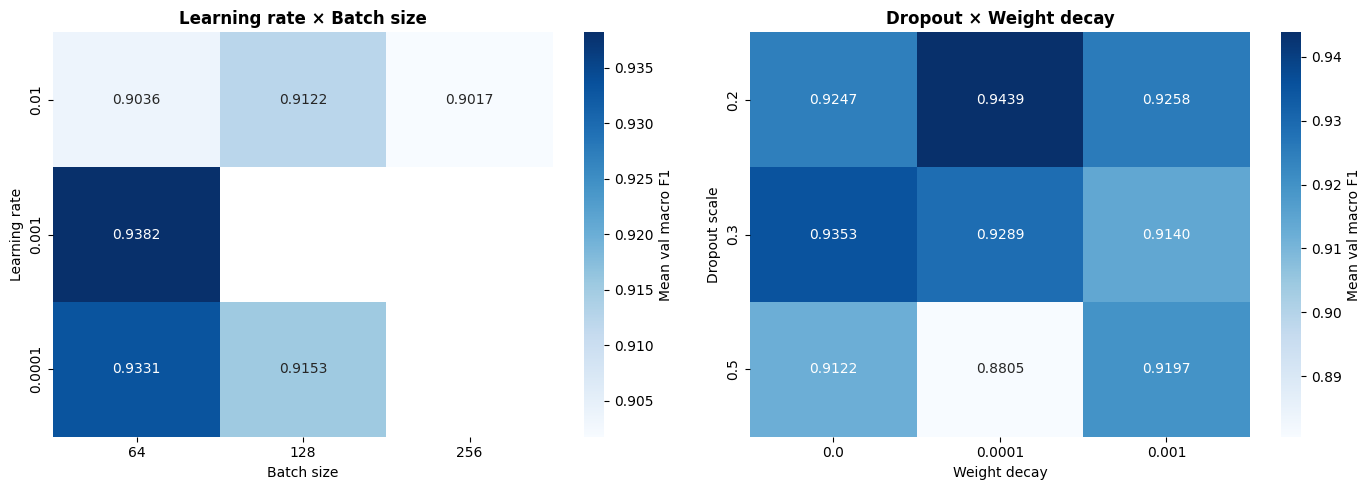

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pv1 = tuning_df.pivot_table(
    index='lr', columns='batch_size', values='val_f1', aggfunc='mean'
).sort_index(ascending=False)
sns.heatmap(pv1, annot=True, fmt='.4f', cmap='Blues', ax=axes[0],
            cbar_kws={'label': 'Mean val macro F1'})
axes[0].set_title('Learning rate × Batch size', fontweight='bold')
axes[0].set_xlabel('Batch size'); axes[0].set_ylabel('Learning rate')

pv2 = tuning_df.pivot_table(
    index='dropout', columns='weight_decay', values='val_f1', aggfunc='mean'
)
sns.heatmap(pv2, annot=True, fmt='.4f', cmap='Blues', ax=axes[1],
            cbar_kws={'label': 'Mean val macro F1'})
axes[1].set_title('Dropout × Weight decay', fontweight='bold')
axes[1].set_xlabel('Weight decay'); axes[1].set_ylabel('Dropout scale')

plt.tight_layout()
# plt.savefig(f'{MODELS_DIR}/tuning_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
print('Top 5 configurations by validation macro F1:\n')
print(tuning_df.head(5).to_string(index=False))

Top 5 configurations by validation macro F1:

    lr  batch_size  dropout  weight_decay  val_loss  val_acc   val_f1  epochs    seconds
0.0010          64      0.2        0.0000  0.029468 0.991630 0.947539      18 657.826443
0.0010          64      0.2        0.0001  0.029474 0.991235 0.943850      20 733.328227
0.0010          64      0.3        0.0001  0.031690 0.990510 0.937953      19 695.035087
0.0001          64      0.3        0.0000  0.033547 0.988467 0.935341      25 918.467175
0.0010          64      0.5        0.0010  0.033630 0.989719 0.934499      25 913.167404


In [19]:
# Pick the winner
best = tuning_df.iloc[0]
BEST_LR      = float(best['lr'])
BEST_BS      = int(best['batch_size'])
BEST_DROPOUT = float(best['dropout'])
BEST_WD      = float(best['weight_decay'])

print('Best configuration:')
print(f'  Learning rate  : {BEST_LR:.0e}')
print(f'  Batch size     : {BEST_BS}')
print(f'  Dropout scale  : {BEST_DROPOUT}')
print(f'  Weight decay   : {BEST_WD}')
print(f'  Val F1 (macro) : {best["val_f1"]:.4f}')
print(f'  Val accuracy   : {best["val_acc"]:.4f}')

Best configuration:
  Learning rate  : 1e-03
  Batch size     : 64
  Dropout scale  : 0.2
  Weight decay   : 0.0
  Val F1 (macro) : 0.9475
  Val accuracy   : 0.9916


## Final training

In [20]:
# Rebuild loaders, model, loss, optimizer using BEST_LR and BEST_BS
torch.manual_seed(42)

train_loader, val_loader, test_loader = make_loaders(BEST_BS)

model = CNNModel(NUM_CLASSES, meta_dim=META_DIM, dropout_scale=BEST_DROPOUT).to(device)


# Loss function
criterion = nn.CrossEntropyLoss()

# AdamW handles weight decay correctly; equals Adam when wd=0
optimizer = optim.AdamW(model.parameters(), lr=BEST_LR, weight_decay=BEST_WD)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-6
)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')


Train batches: 2471
Val batches  : 238
Test batches : 238


## Training loop with early stopping

In [21]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_f1': [], 'val_f1': []}
best_val_loss = float('inf')
epochs_without_improvement = 0
ckpt_path = f'{MODELS_DIR}/cnn_baseline.pt'

print('Training...\n')
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc, va_f1, _, _ = run_epoch(model, val_loader,   criterion)

    scheduler.step(va_loss)

    # Append metrics to history
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(va_f1)

    # Check for improvement
    improved = va_loss < best_val_loss
    if improved:
        best_val_loss = va_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), ckpt_path)
    else:
        epochs_without_improvement += 1

    print(f'Epoch {epoch:3d}/{EPOCHS} | '
          f'train loss={tr_loss:.4f} acc={tr_acc:.4f} | '
          f'val loss={va_loss:.4f} acc={va_acc:.4f}')

    if epochs_without_improvement >= PATIENCE:
        print(f'\nEarly stopping: no improvement for {PATIENCE} epochs')
        break

print(f'\nBest val loss: {best_val_loss:.4f}')

Training...

Epoch   1/50 | train loss=0.3695 acc=0.8784 | val loss=0.1679 acc=0.9416
Epoch   2/50 | train loss=0.1263 acc=0.9579 | val loss=0.0693 acc=0.9768
Epoch   3/50 | train loss=0.0932 acc=0.9682 | val loss=0.0414 acc=0.9864
Epoch   4/50 | train loss=0.0741 acc=0.9749 | val loss=0.0449 acc=0.9852
Epoch   5/50 | train loss=0.0648 acc=0.9783 | val loss=0.0431 acc=0.9856
Epoch   6/50 | train loss=0.0575 acc=0.9806 | val loss=0.0553 acc=0.9812
Epoch   7/50 | train loss=0.0516 acc=0.9829 | val loss=0.0363 acc=0.9891
Epoch   8/50 | train loss=0.0486 acc=0.9838 | val loss=0.0323 acc=0.9898
Epoch   9/50 | train loss=0.0446 acc=0.9854 | val loss=0.0320 acc=0.9904
Epoch  10/50 | train loss=0.0419 acc=0.9862 | val loss=0.0366 acc=0.9878
Epoch  11/50 | train loss=0.0394 acc=0.9871 | val loss=0.0318 acc=0.9906
Epoch  12/50 | train loss=0.0360 acc=0.9880 | val loss=0.0333 acc=0.9904
Epoch  13/50 | train loss=0.0351 acc=0.9887 | val loss=0.0433 acc=0.9866
Epoch  14/50 | train loss=0.0322 acc=0

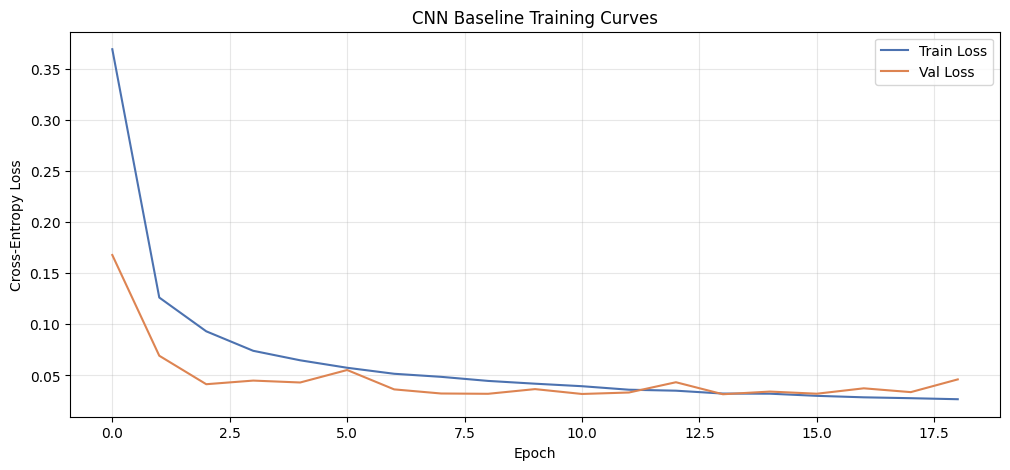

In [22]:
# Training curves
fig = plt.figure(figsize=(12, 5))
plt.plot(history['train_loss'], label='Train Loss', color='#4C72B0')
plt.plot(history['val_loss'], label='Val Loss', color='#DD8452')
set_title = 'CNN Baseline Training Curves'
plt.title(set_title)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

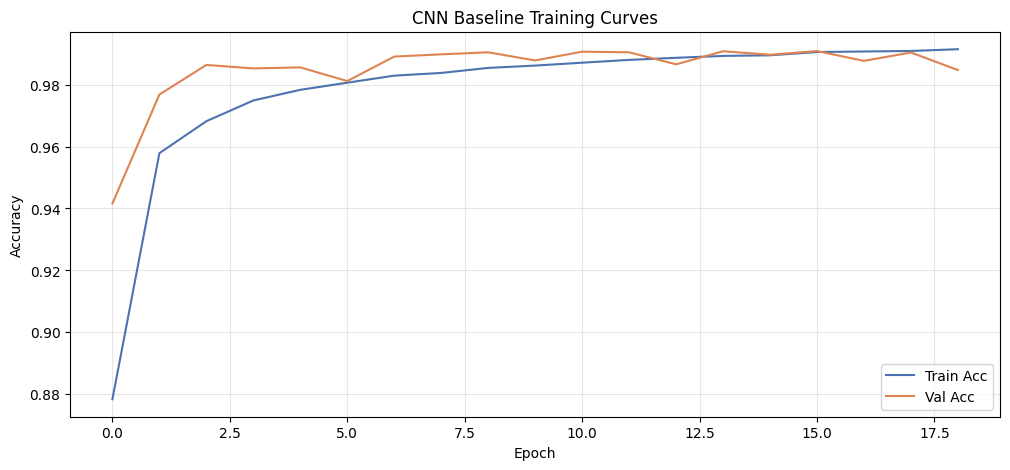

In [23]:
# Training accuracy curves
fig = plt.figure(figsize=(12, 5))
plt.plot(history['train_acc'], label='Train Acc', color='#4C72B0')
plt.plot(history['val_acc'], label='Val Acc', color='#DD8452')
set_title = 'CNN Baseline Training Curves'
plt.title(set_title)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Test set evaluation

In [24]:
# Reload best weights

model.load_state_dict(torch.load(ckpt_path, map_location=device))

test_loss, test_acc, test_f1, y_true, y_pred = run_epoch(model, test_loader, criterion)

print(f'Test loss         : {test_loss:.4f}')
print(f'Test accuracy     : {test_acc:.4f}')
print(f'Test F1 (macro)   : {test_f1:.4f}\n')

report = classification_report(y_true, y_pred, target_names=LABEL_NAMES, digits=4)
print(report)

# Save results
with open(f'{MODELS_DIR}/cnn_baseline_report.txt', 'w') as f:
    f.write(f'CNN Baseline (PyTorch) — use_smote={USE_SMOTE}\n')
    f.write(f'Best config: lr={BEST_LR:.0e}, batch_size={BEST_BS}, '
            f'dropout={BEST_DROPOUT}, weight_decay={BEST_WD}\n')
    f.write('=' * 60 + '\n\n')
    f.write(f'Test loss        : {test_loss:.4f}\n')
    f.write(f'Test accuracy    : {test_acc:.4f}\n')
    f.write(f'Test F1 (macro)  : {test_f1:.4f}\n\n')
    f.write(report)

np.save(f'{MODELS_DIR}/cnn_baseline_history.npy', history, allow_pickle=True)

Test loss         : 0.0374
Test accuracy     : 0.9902
Test F1 (macro)   : 0.9304

                precision    recall  f1-score   support

    N (Normal)     0.9946    0.9960    0.9953     13552
S (Supravent.)     0.9229    0.8897    0.9060       417
  V (Ventric.)     0.9813    0.9677    0.9745      1085
    F (Fusion)     0.8106    0.8843    0.8458       121

      accuracy                         0.9902     15175
     macro avg     0.9274    0.9344    0.9304     15175
  weighted avg     0.9902    0.9902    0.9902     15175



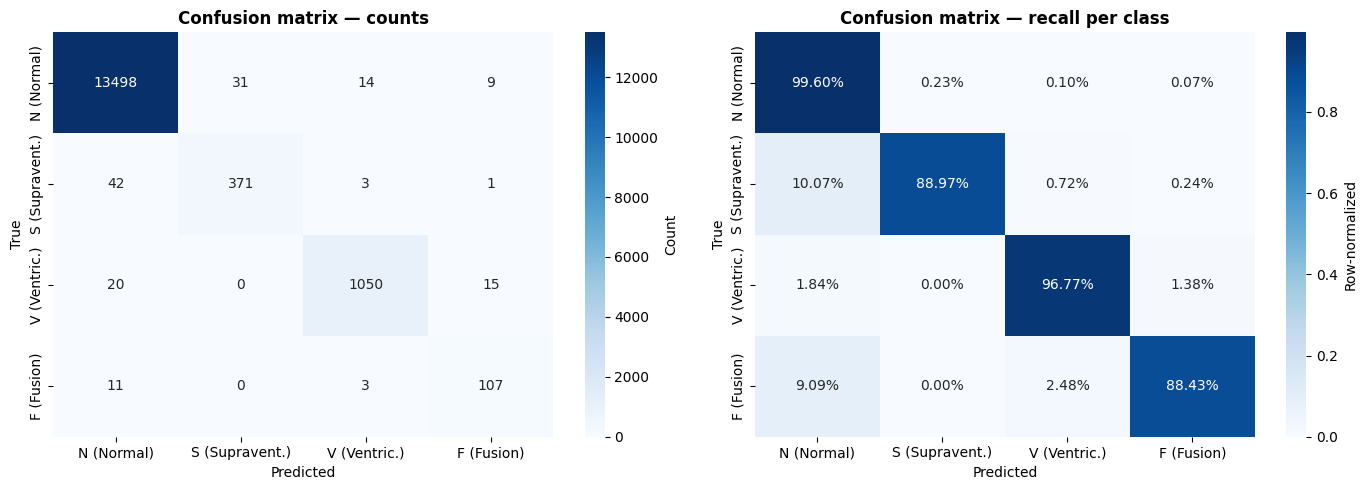

In [25]:
# Confusion matrix
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
# Heatmap with annotations, class labels, and colorbar
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion matrix — counts', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            cbar_kws={'label': 'Row-normalized'})
axes[1].set_title('Confusion matrix — recall per class', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/cnn_baseline_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

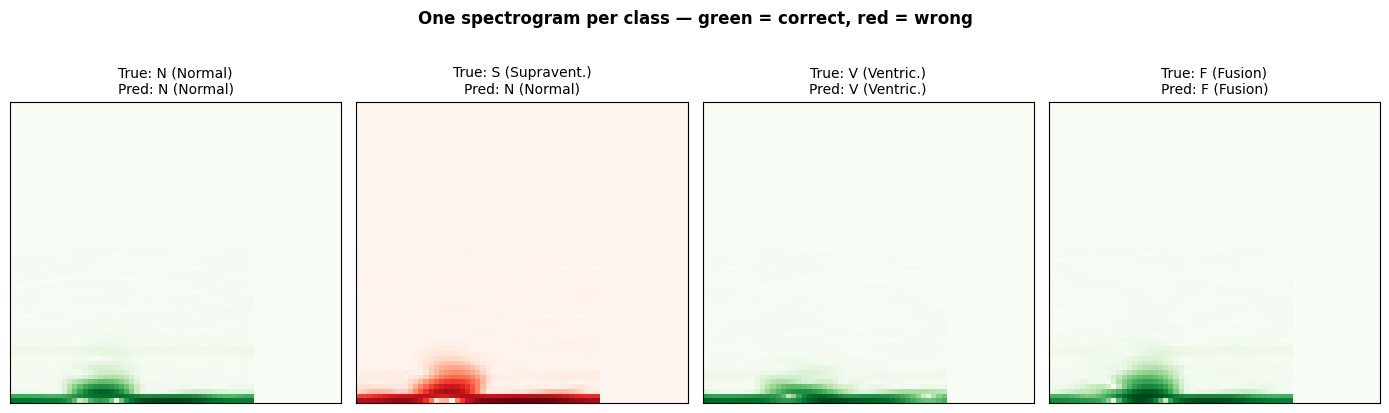

In [31]:
model.eval()
# Pick one example per class instead of random sampling
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for cls in range(NUM_CLASSES):
    # Find first test sample of this class
    idx = (y_test == cls).nonzero(as_tuple=True)[0][0].item()
    spec = specs_test[idx:idx+1].to(device)
    meta = meta_test[idx:idx+1].to(device)

    with torch.no_grad():
        pred = model(spec, meta).argmax(1).item()

    correct = cls == pred
    axes[cls].imshow(specs_test[idx, 0].numpy(), aspect='auto', origin='lower',
                     cmap='Greens' if correct else 'Reds')
    axes[cls].set_title(f'True: {LABEL_NAMES[cls]}\nPred: {LABEL_NAMES[pred]}', fontsize=10)
    axes[cls].set_xticks([]); axes[cls].set_yticks([])

plt.suptitle('One spectrogram per class — green = correct, red = wrong',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [32]:
summary = tuning_df[
    ['lr', 'batch_size', 'dropout', 'weight_decay', 'val_loss', 'val_acc', 'val_f1']
].copy()
summary['lr'] = summary['lr'].apply(lambda x: f'{x:.0e}')
summary.columns = ['Learning rate', 'Batch size', 'Dropout', 'Weight decay',
                   'Val loss', 'Val accuracy', 'Val macro F1']
print('Hyperparameter search results (sorted by val F1):')
print(summary.to_string(index=False))
print()
print('Best config retrained on full training budget:')
print(f'  Learning rate : {BEST_LR:.0e}')
print(f'  Batch size    : {BEST_BS}')
print(f'  Dropout       : {BEST_DROPOUT}')
print(f'  Weight decay  : {BEST_WD}')
print(f'  Test accuracy : {test_acc:.4f}')
print(f'  Test F1 macro : {test_f1:.4f}')

Hyperparameter search results (sorted by val F1):
Learning rate  Batch size  Dropout  Weight decay  Val loss  Val accuracy  Val macro F1
        1e-03          64      0.2        0.0000  0.029468      0.991630      0.947539
        1e-03          64      0.2        0.0001  0.029474      0.991235      0.943850
        1e-03          64      0.3        0.0001  0.031690      0.990510      0.937953
        1e-04          64      0.3        0.0000  0.033547      0.988467      0.935341
        1e-03          64      0.5        0.0010  0.033630      0.989719      0.934499
        1e-04          64      0.3        0.0001  0.034310      0.988335      0.930871
        1e-03          64      0.2        0.0010  0.033288      0.989258      0.927090
        1e-04         128      0.2        0.0010  0.037226      0.987479      0.924483
        1e-02         256      0.2        0.0000  0.037163      0.987742      0.922962
        1e-04         128      0.3        0.0001  0.039058      0.987083      0.